# EC1036 - Inteligência Computacional
## Tópico: Regressão Linear

Ao contrário dos classificadores, como k-NN e Decision Stump que veremos mais adiante, a Regressão Linear tem como objetivo prever um valor numérico contínuo, ajustando uma relação entre as variáveis de entrada e a saída desejada.

## 1. O modelo Matemático

A ideia é encontrar uma linha (ou hiperplano) que melhor se ajuste aos dados. A fórmula básica para uma previsão $\hat{y}$ é:

$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n
$$

Sendo:

- $\hat{y}$: Valor previsto pelo modelo.
- $n$: Número de características (features) do dado.
- $x_i$: Valor da $i$-ésima característica.
- $\theta_0$: Bias (viés) ou intercepto, o ponto onde a linha cruza o eixo vertical.
- $\theta_j$: Pesos (parâmetros) do modelo para cada característica.

Em aprendizado de máquina, costumamos usar a forma vetorizada:

$$
\hat{y} = h_{\theta}(x) = \theta \cdot x
$$

onde $x_0$ é sempre igual a 1 para multiplicar o termo de bias $\theta_0$.

## 2. Treinando o modelo de regressão linear

A medida de desempenho mais comum de um modelo de regressão é o **Root Mean Square Error (RMSE)**. Portanto, para treinar um modelo de Regressão Linear, precisamos encontrar o valor de $\theta$ que minimize o RMSE. Na prática, é mais simples minimizar o **erro quadrático médio (MSE)** do que o RMSE, e leva ao mesmo resultado (porque o valor que minimiza uma função também minimiza sua raiz quadrada).

A função de custo (MSE) é dada por:

$$
MSE(X, h_{\theta}) = \frac{1}{m} \sum_{i=1}^{m} (\theta^T x^{(i)} - y^{(i)})^2
$$

O objetivo no treinamento é encontrar os valores de $\theta$ que minimizam esse erro.

## 3. Equação normal

Existe uma solução matemática direta para encontrar os melhores parâmetros sem precisar de tentativas e erros exaustivos. Ela é chamada de **Equação Normal**:

$$
\hat{\theta} = (X^T X)^{-1} X^T y
$$

Onde:
- $\hat{\theta}$: Vetor de parâmetros que minimiza a função de custo.
- $X$: Matriz de atributos (com uma coluna de 1s para o termo de bias).
- $X^{T}$: Transposta da matriz $X$.
- $y$: Vetor contendo os valores alvo (corretos) do treinamento.

Essa equação fornece a solução ótima para os parâmetros da regressão linear quando $X^T X$ é invertível.

----

**NOTA**

Em Aprendizado de Máquina, os vetores são frequentemente representados como vetores coluna, ou seja, matrizes 2D com uma única coluna. Se $\theta$ e $x$ são vetores coluna, então a previsão é:

$$
\hat{y} = \theta^\top x
$$

onde $\theta^\top$ é a transposta de $\theta$ (um vetor linha em vez de um vetor coluna) e $\theta^\top x$ é a multiplicação de matrizes de $\theta^\top$ por $x$. O resultado é matematicamente equivalente à previsão escalar, mas agora representado como uma matriz $1 \times 1$ (uma única célula).

### 4. Exemplo Prático com m = 2 Exemplos

Para entender como a Equação Normal ($\hat{\theta} = (X^T X)^{-1} X^T y$) funciona na prática, vamos considerar um caso extremamente simples com apenas 2 exemplos de treinamento:

**Dados de Treino:**
1. Instância 1: $x^{(1)} = 1$ (valor da característica), $y^{(1)} = 2$ (alvo)
2. Instância 2: $x^{(2)} = 2$ (valor da característica), $y^{(2)} = 3$ (alvo)

Lembrando que adicionamos sempre $x_0 = 1$ para o bias, nossas matrizes ficam:

$$X = \begin{bmatrix} 1 & 1 \\ 1 & 2 \end{bmatrix}, \quad y = \begin{bmatrix} 2 \\ 3 \end{bmatrix}$$

#### Passo a Passo da Resolução:

1. **Calcular $X^T X$:**
   $$\begin{bmatrix} 1 & 1 \\ 1 & 2 \end{bmatrix} \begin{bmatrix} 1 & 1 \\ 1 & 2 \end{bmatrix} = \begin{bmatrix} 2 & 3 \\ 3 & 5 \end{bmatrix}$$

2. **Calcular a Inversa $(X^T X)^{-1}$:**
   - Aplicando à matriz:
     $$\text{det} = (2 \cdot 5) - (3 \cdot 3) = 10 - 9 = 1$$
   - Fórmula da inversa:
     $$A^{-1} = \frac{1}{\det(A)} \begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$
   - Portanto:
     $$(X^T X)^{-1} = \frac{1}{1} \begin{bmatrix} 5 & -3 \\ -3 & 2 \end{bmatrix} = \begin{bmatrix} 5 & -3 \\ -3 & 2 \end{bmatrix}$$

*Obs: Só é possível calcular a inversa de uma matriz quadrada se seu determinante for diferente de zero. Se o determinante for zero, a matriz é singular (não invertível) e a Equação Normal não pode ser usada diretamente para encontrar os parâmetros ótimos.*

3. **Calcular $X^T y$:**
   $$\begin{bmatrix} 1 & 1 \\ 1 & 2 \end{bmatrix} \begin{bmatrix} 2 \\ 3 \end{bmatrix} = \begin{bmatrix} 5 \\ 8 \end{bmatrix}$$

4. **Resultado Final ($\hat{\theta}$):**
   $$\hat{\theta} = \begin{bmatrix} 5 & -3 \\ -3 & 2 \end{bmatrix} \begin{bmatrix} 5 \\ 8 \end{bmatrix} = \begin{bmatrix} 25 - 24 \\ -15 + 16 \end{bmatrix} = \begin{bmatrix} 1 \\ 1 \end{bmatrix}$$

**Conclusão:** O modelo encontrou $\theta_0 = 1$ e $\theta_1 = 1$. A reta de previsão é $\hat{y} = 1 + 1x$.

## 5. Exemplo em python

Previsão para 85m²: R$ 291.55 mil


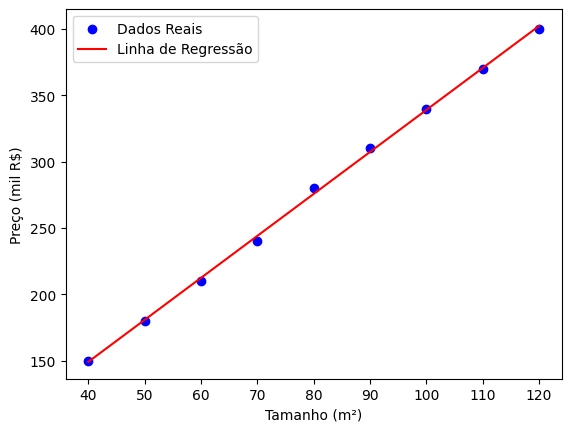

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 1. Criando dados fictícios
# X = Tamanho em m² (Nossa "Feature")
# y = Preço em R$ (Nosso "Target")
X = np.array([[40], [50], [60], [70], [80], [90], [100], [110], [120]])
y = np.array([150, 180, 210, 240, 280, 310, 340, 370, 400])

# 2. Dividindo os dados em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Criando e treinando o modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train) 

# 4. Fazendo uma previsão
tamanho_novo = np.array([[85]]) # Queremos saber o preço de uma casa de 85m²
preco_previsto = modelo.predict(tamanho_novo)

print(f"Previsão para 85m²: R$ {preco_previsto[0]:.2f} mil")

# 5. Visualizando os resultados
plt.scatter(X, y, color='blue', label='Dados Reais')
plt.plot(X, modelo.predict(X), color='red', label='Linha de Regressão')
plt.xlabel('Tamanho (m²)')
plt.ylabel('Preço (mil R$)')
plt.legend()
plt.show()